In [ ]:
#Use DecisionTree to design and train a model for predicting the student performance based on the features we discussed and tried practically. Try to vary the depth (maxdepth=3,4,5) and do a comparative analysis for it's impact on the model's performance.

Student Dataset:


,study_hours,attendance,previous_score,assignment_score,result
0,2,60,45,40,Fail
1,3,65,50,48,Fail
2,5,75,65,70,Pass
3,6,80,70,75,Pass
4,8,90,85,88,Pass
5,1,50,35,30,Fail
6,4,70,60,65,Pass
7,7,85,80,82,Pass
8,2,55,40,38,Fail
9,9,95,90,92,Pass


--------------------------------
Decision Tree Max Depth: 3
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

--------------------------------
Decision Tree Max Depth: 4
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6

--------------------------------
Decision Tree Max Depth: 5
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   suppor

,Max Depth,Accuracy
0,3,1.0
1,4,1.0
2,5,1.0


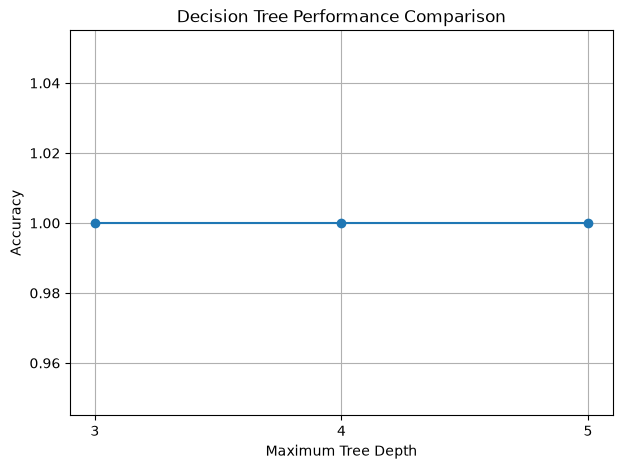

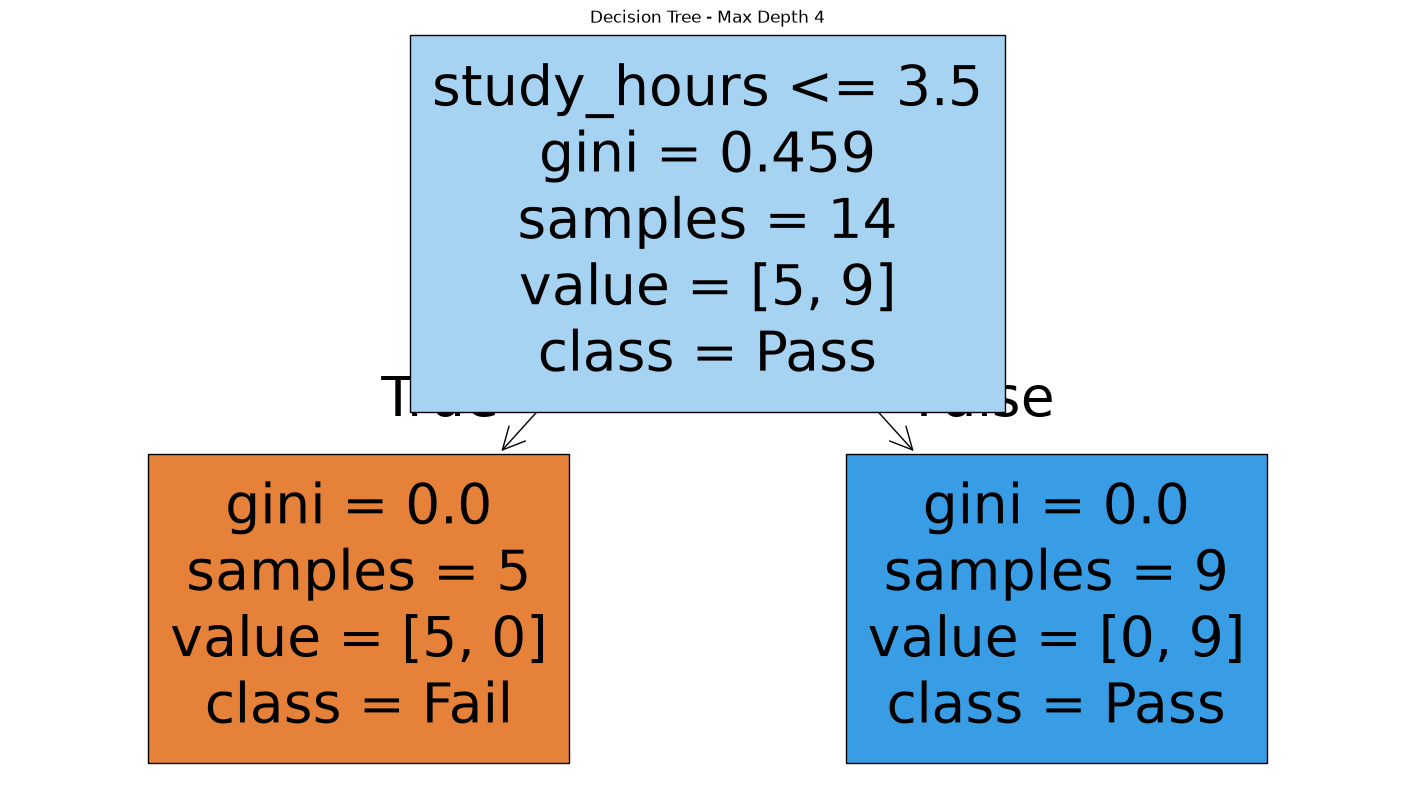

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree


# ------------------------------------------------
# 1. Create Student Dataset
# ------------------------------------------------

data = {
    "study_hours": [2, 3, 5, 6, 8, 1, 4, 7, 2, 9,
                    3, 6, 5, 1, 8, 4, 7, 2, 9, 5],

    "attendance": [60, 65, 75, 80, 90, 50, 70, 85, 55, 95,
                   68, 82, 78, 45, 92, 72, 88, 58, 96, 76],

    "previous_score": [45, 50, 65, 70, 85, 35, 60, 80, 40, 90,
                       55, 75, 68, 30, 88, 62, 82, 42, 94, 72],

    "assignment_score": [40, 48, 70, 75, 88, 30, 65, 82, 38, 92,
                         52, 78, 72, 28, 90, 60, 85, 35, 95, 74],

    "result": [
        "Fail", "Fail", "Pass", "Pass", "Pass",
        "Fail", "Pass", "Pass", "Fail", "Pass",
        "Fail", "Pass", "Pass", "Fail", "Pass",
        "Pass", "Pass", "Fail", "Pass", "Pass"
    ]
}

df = pd.DataFrame(data)

print("Student Dataset:")
display(df)


# ------------------------------------------------
# 2. Separate Features and Target
# ------------------------------------------------

X = df[
    ["study_hours",
     "attendance",
     "previous_score",
     "assignment_score"]
]

y = df["result"]


# ------------------------------------------------
# 3. Split Data
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ------------------------------------------------
# 4. Train Decision Trees with Different Depths
# ------------------------------------------------

depths = [3, 4, 5]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy
    })

    print("--------------------------------")
    print("Decision Tree Max Depth:", depth)
    print("Accuracy:", accuracy)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# ------------------------------------------------
# 5. Comparison
# ------------------------------------------------

results_df = pd.DataFrame(results)

print("\nComparison:")
display(results_df)


# ------------------------------------------------
# 6. Plot Accuracy Comparison
# ------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    results_df["Max Depth"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance Comparison")

plt.xticks(depths)
plt.grid(True)

plt.show()


# ------------------------------------------------
# 7. Visualize Decision Tree
# ------------------------------------------------

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("Decision Tree - Max Depth 4")
plt.show()

In [ ]:
#Write python code to demonstrate application of linear regression in electronics industry.

Electronics Dataset:


,temperature,power_consumption
0,20,50
1,22,52
2,24,55
3,26,58
4,28,61
5,30,64
6,32,67
7,34,70
8,36,74
9,38,77


Predicted Power Consumption:
[77.69142631 84.32595812 47.83603319]

Intercept: 14.663374160410918
Coefficient: 1.6586329514026072

Model Performance
-------------------------
Mean Absolute Error: 1.060450414855789
Mean Squared Error: 1.7556904680916159
R2 Score: 0.9918297754845788

Predicted power consumption at 35°C: 72.71552745950217


C:\Users\Deepak Prajapati\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


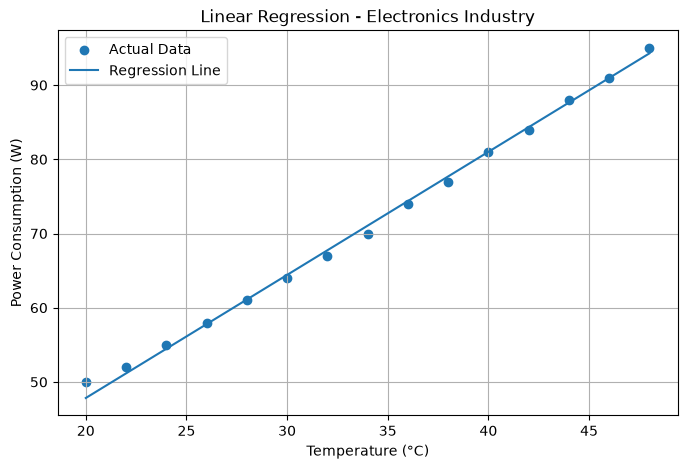

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Create Electronics Dataset
# ------------------------------------------------

data = {
    "temperature": [
        20, 22, 24, 26, 28,
        30, 32, 34, 36, 38,
        40, 42, 44, 46, 48
    ],

    "power_consumption": [
        50, 52, 55, 58, 61,
        64, 67, 70, 74, 77,
        81, 84, 88, 91, 95
    ]
}

df = pd.DataFrame(data)

print("Electronics Dataset:")
display(df)


# ------------------------------------------------
# 2. Define X and Y
# ------------------------------------------------

X = df[["temperature"]]

y = df["power_consumption"]


# ------------------------------------------------
# 3. Split Dataset
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------
# 4. Create Linear Regression Model
# ------------------------------------------------

model = LinearRegression()


# ------------------------------------------------
# 5. Train Model
# ------------------------------------------------

model.fit(X_train, y_train)


# ------------------------------------------------
# 6. Prediction
# ------------------------------------------------

y_pred = model.predict(X_test)

print("Predicted Power Consumption:")
print(y_pred)


# ------------------------------------------------
# 7. Model Coefficients
# ------------------------------------------------

print("\nIntercept:", model.intercept_)
print("Coefficient:", model.coef_[0])


# ------------------------------------------------
# 8. Model Evaluation
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("-------------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


# ------------------------------------------------
# 9. Predict Power for New Temperature
# ------------------------------------------------

new_temperature = [[35]]

prediction = model.predict(new_temperature)

print(
    "\nPredicted power consumption at 35°C:",
    prediction[0]
)


# ------------------------------------------------
# 10. Visualization
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    X,
    y,
    label="Actual Data"
)

plt.plot(
    X,
    model.predict(X),
    label="Regression Line"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression - Electronics Industry")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Demonstrate application of unsupervised learning to train a model (choose any data of your choice).

Customer Dataset:


,annual_income,spending_score
0,15,80
1,16,85
2,17,78
3,18,82
4,20,88
5,40,50
6,42,55
7,45,48
8,46,52
9,48,45



Clustered Data:


,annual_income,spending_score,Cluster
0,15,80,2
1,16,85,2
2,17,78,2
3,18,82,2
4,20,88,2
5,40,50,0
6,42,55,0
7,45,48,0
8,46,52,0
9,48,45,0



Cluster Centers:
[[44.2 50. ]
 [75.  22.6]
 [17.2 82.6]]


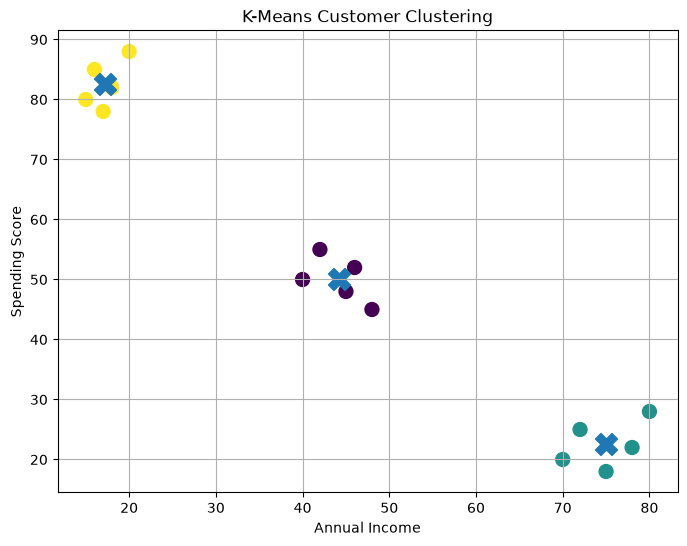

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans


# ------------------------------------------------
# 1. Create Customer Dataset
# ------------------------------------------------

data = {
    "annual_income": [
        15, 16, 17, 18, 20,
        40, 42, 45, 46, 48,
        70, 72, 75, 78, 80
    ],

    "spending_score": [
        80, 85, 78, 82, 88,
        50, 55, 48, 52, 45,
        20, 25, 18, 22, 28
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
display(df)


# ------------------------------------------------
# 2. Select Features
# ------------------------------------------------

X = df[
    ["annual_income", "spending_score"]
]


# ------------------------------------------------
# 3. Create K-Means Model
# ------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)


# ------------------------------------------------
# 4. Train Model
# ------------------------------------------------

kmeans.fit(X)


# ------------------------------------------------
# 5. Get Cluster Labels
# ------------------------------------------------

df["Cluster"] = kmeans.labels_

print("\nClustered Data:")
display(df)


# ------------------------------------------------
# 6. Find Cluster Centers
# ------------------------------------------------

print("\nCluster Centers:")
print(kmeans.cluster_centers_)


# ------------------------------------------------
# 7. Visualize Clusters
# ------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    df["annual_income"],
    df["spending_score"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=250
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Clustering")

plt.grid(True)

plt.show()